In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("default")

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 1: Load and Inspect Historical Data

In this step, we load the historical robot sensor dataset from a local CSV file and perform an initial inspection of the data structure.  
This historical dataset serves as the **baseline reference** for all subsequent modeling, residual analysis, and anomaly detection tasks.

Specifically, this step is used to:

1. Train univariate linear regression models (Time → Axes #1–#8)
2. Analyze residual behavior under normal operating conditions
3. Discover data-driven anomaly thresholds
4. Establish a clean and well-understood baseline before introducing streaming data

At the end of this step, we also validate connectivity to a Neon-hosted PostgreSQL database.  
This database connection will be used in later steps to simulate time-based data streaming, persist anomaly events, and support database-backed querying and visualization.




In [2]:
# Step 1.1: Load Historical Sensor Data

# Relative path from notebooks/ to data/
data_path = "../data/RMBR4-2_export_test.csv"

# Load CSV into DataFrame
df = pd.read_csv(data_path)

# Basic shape of the dataset
print("Dataset shape:", df.shape)

# Preview first few rows
df.head()


Dataset shape: (39672, 16)


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z


In [3]:
# Step 1.2: Inspect Columns and Data Types

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 39672 entries, 0 to 39671
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Trait     39672 non-null  str    
 1   Axis #1   39672 non-null  float64
 2   Axis #2   39672 non-null  float64
 3   Axis #3   39672 non-null  float64
 4   Axis #4   39672 non-null  float64
 5   Axis #5   39672 non-null  float64
 6   Axis #6   39672 non-null  float64
 7   Axis #7   39672 non-null  float64
 8   Axis #8   39672 non-null  float64
 9   Axis #9   0 non-null      float64
 10  Axis #10  0 non-null      float64
 11  Axis #11  0 non-null      float64
 12  Axis #12  0 non-null      float64
 13  Axis #13  0 non-null      float64
 14  Axis #14  0 non-null      float64
 15  Time      39672 non-null  str    
dtypes: float64(14), str(2)
memory usage: 4.8 MB


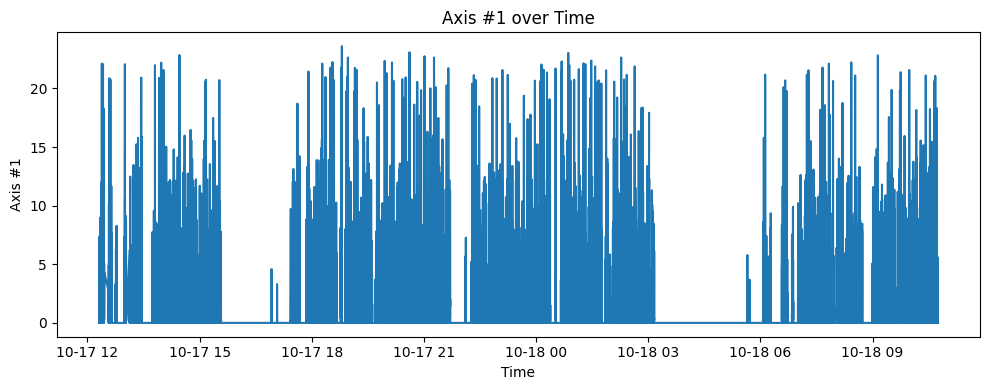

In [4]:
# Step 1.3: Quick Visualization of One Axis over Time

# Explicitly select time and axis columns
time_col = "Time"
axis_col = "Axis #1"

# Convert Time column to datetime
df[time_col] = pd.to_datetime(df[time_col])

plt.figure(figsize=(10, 4))
plt.plot(df[time_col], df[axis_col])
plt.xlabel("Time")
plt.ylabel(axis_col)
plt.title(f"{axis_col} over Time")
plt.tight_layout()
plt.show()



In [5]:
# Step 1.4: Basic Descriptive Statistics


df.describe()


,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14
count,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,0.725743,3.613374,2.710336,0.620222,0.954521,0.599427,0.870145,0.102214,NaN,NaN,NaN,NaN,NaN,NaN
std,2.162120,6.879962,5.111901,1.574897,2.100186,1.815498,2.166811,0.423075,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.312710,4.217190,4.586190,0.516190,0.800090,0.361330,0.310030,0.078480,NaN,NaN,NaN,NaN,NaN,NaN
max,23.609300,51.713230,41.855560,15.666300,20.750760,20.931420,8.108480,5.905640,NaN,NaN,NaN,NaN,NaN,NaN


## Step 1.5: Filter by Trait and Prepare Data for Modeling

The dataset contains multiple sensor traits (e.g., current, voltage).
In this lab, we focus on a single trait to simplify modeling and analysis.

This step:
1, Filters the dataset by a selected trait

2, Converts time to a proper datetime format

3, Selects valid axis columns for regression modeling


In [6]:
# Step 1.5.1: Filter Data by Trait

# Select a single trait for analysis
selected_trait = "current"

df_trait = df[df["Trait"] == selected_trait].copy()

print("Filtered dataset shape:", df_trait.shape)
df_trait.head()


Filtered dataset shape: (39672, 16)


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:23.660000+00:00
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:25.472000+00:00
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:27.348000+00:00
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:29.222000+00:00
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:31.117000+00:00


In [7]:
# Step 1.5.2: Convert Time Column to Datetime

df_trait["Time"] = pd.to_datetime(df_trait["Time"])

# Sort by time to ensure correct temporal order
df_trait = df_trait.sort_values("Time")

df_trait[["Time"]].head()


,Time
0,2022-10-17 12:18:23.660000+00:00
1,2022-10-17 12:18:25.472000+00:00
2,2022-10-17 12:18:27.348000+00:00
3,2022-10-17 12:18:29.222000+00:00
4,2022-10-17 12:18:31.117000+00:00


In [8]:
# Step 1.5.3: Select Axis Columns for Modeling

axis_columns = [f"Axis #{i}" for i in range(1, 9)]

# Verify columns exist
axis_columns = [col for col in axis_columns if col in df_trait.columns]

print("Axis columns selected for modeling:")
axis_columns

df_trait[axis_columns].head()


Axis columns selected for modeling:


,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Step 1.5.4: Handle Missing Values

# Drop rows with missing values in selected axes
df_model = df_trait[["Time"] + axis_columns].dropna()

print("Modeling dataset shape:", df_model.shape)
df_model.head()


Modeling dataset shape: (39672, 9)


,Time,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8
0,2022-10-17 12:18:23.660000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17 12:18:25.472000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17 12:18:27.348000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17 12:18:29.222000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17 12:18:31.117000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Step 1.6 – Database Connectivity Validation (Neon PostgreSQL)

In this step, we verified connectivity to a managed PostgreSQL database hosted on Neon.tech using SQLAlchemy.  
A simple validation query (`SELECT 1`) was executed successfully, confirming that the database credentials, SSL configuration, and client libraries are correctly configured.

This connection will be used in subsequent steps to simulate streaming data ingestion and to support real-time anomaly detection workflows backed by a relational database.




In [10]:
# Step 1.6.1: Import database-related libraries
# SQLAlchemy is used to manage database connections
# Pandas is used to interact with SQL query results
# and convert them into DataFrames when needed

from sqlalchemy import create_engine,text
import pandas as pd


In [11]:
# Step 1.6.2: Connect to Neon PostgreSQL Database (Connection Test)

# Neon connection string (provided)
DATABASE_URL = (
    "postgresql+psycopg2://neondb_owner:npg_qo5Qk7OLZrDh"
    "@ep-still-sky-ahfk927j-pooler.c-3.us-east-1.aws.neon.tech"
    ":5432/neondb"
    "?sslmode=require&channel_binding=require"
)

# Create SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# Test connection with a simple query
with engine.connect() as connection:
    result = connection.execute(text("SELECT 1"))
    print("Neon connection successful:", result.scalar())



Neon connection successful: 1


## Step 2: Train Linear Regression Models

In this step, linear regression models are trained to learn the normal
baseline behavior of each robot axis over time.

The trained models will later be used to:

1，Compute residuals (actual − predicted)

2，Discover data-driven thresholds

3， Detect abnormal behavior during streaming


In [12]:
# Step 2.1: Convert Time to Numeric Feature

# Create a numeric time feature (seconds since start)
t0 = df_model["Time"].min()
df_model["time_seconds"] = (df_model["Time"] - t0).dt.total_seconds()

df_model[["Time", "time_seconds"]].head()


,Time,time_seconds
0,2022-10-17 12:18:23.660000+00:00,0.000
1,2022-10-17 12:18:25.472000+00:00,1.812
2,2022-10-17 12:18:27.348000+00:00,3.688
3,2022-10-17 12:18:29.222000+00:00,5.562
4,2022-10-17 12:18:31.117000+00:00,7.457


In [13]:
# Step 2.2: Train Linear Regression for Axis #1 (Example)

X = df_model[["time_seconds"]].values
y = df_model["Axis #1"].values

lr_example = LinearRegression()
lr_example.fit(X, y)

print("Axis #1 Regression Model")
print("Slope:", lr_example.coef_[0])
print("Intercept:", lr_example.intercept_)


Axis #1 Regression Model
Slope: -1.1767285669287817e-07
Intercept: 0.730542085743738


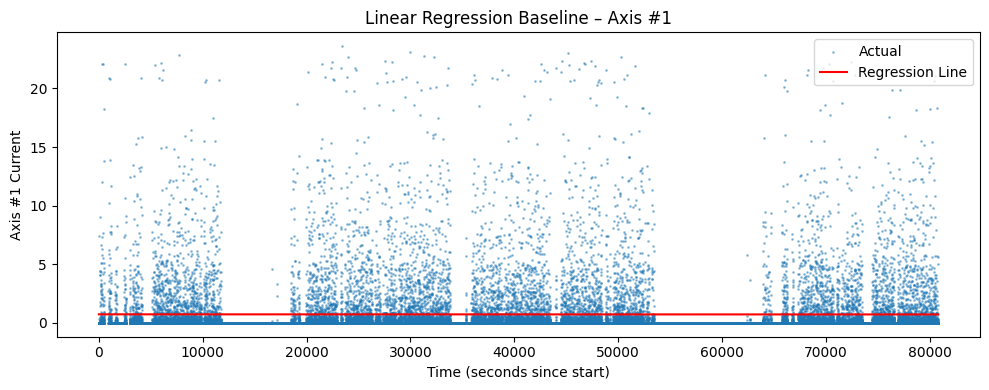

In [14]:
# Step 2.3: Visualize Regression Baseline for Axis #1

y_pred = lr_example.predict(X)

plt.figure(figsize=(10, 4))
plt.scatter(df_model["time_seconds"], y, s=1, alpha=0.4, label="Actual")
plt.plot(df_model["time_seconds"], y_pred, color="red", label="Regression Line")
plt.xlabel("Time (seconds since start)")
plt.ylabel("Axis #1 Current")
plt.title("Linear Regression Baseline – Axis #1")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# Step 2.4 – Train Linear Regression Models for All Valid Axes


regression_models = {}
regression_params = []

for axis in axis_columns:
    X = df_model[["time_seconds"]].values
    y = df_model[axis].values

    lr = LinearRegression()
    lr.fit(X, y)

    regression_models[axis] = lr
    regression_params.append({
        "Axis": axis,
        "Slope": lr.coef_[0],
        "Intercept": lr.intercept_
    })

regression_summary = pd.DataFrame(regression_params)
regression_summary


,Axis,Slope,Intercept
0,Axis #1,-1.176729e-07,0.730542
1,Axis #2,2.194203e-06,3.523886
2,Axis #3,-5.777186e-07,2.733898
3,Axis #4,3.890034e-07,0.604357
4,Axis #5,8.381178e-08,0.951103
5,Axis #6,4.744455e-07,0.580077
6,Axis #7,5.537186e-07,0.847563
7,Axis #8,8.499989e-08,0.098748


### Step 2.5 – Interpretation of Regression Models

The linear regression models capture the baseline current behavior
of each robot axis over time.

Most slopes are close to zero, indicating stable baseline behavior
during idle and normal operation periods.

These baseline models will be used to compute residuals in the next step.


## Step 3: Deviation-Based Anomaly Detection Using Regression Baselines

In this step, we analyze how actual sensor readings deviate **above** the predicted baseline values learned by the linear regression models.

Instead of treating deviations symmetrically, we focus on **positive deviations above the regression baseline**, as sustained abnormal increases in current are more indicative of potential faults or system degradation in predictive maintenance scenarios.

The process in this step includes:

1. Computing **deviation above the regression baseline** as (actual value − predicted value), ignoring negative deviations
2. Discovering **data-driven thresholds (MinC and MaxC)** from normal operating behavior using statistical percentiles
3. Identifying time points where deviations exceed these thresholds
4. Merging **consecutive threshold exceedances over a minimum duration (T seconds)** into Alert and Error events

An **Alert** is triggered when the deviation exceeds MinC continuously for at least T seconds, while an **Error** is triggered when the deviation exceeds MaxC continuously for at least T seconds.

These detected Alert and Error events will later be used for alerting during simulated data streaming and persisted for downstream analysis.



In [16]:
# Step 3.1: Compute Deviation Above Regression Baseline for Axis #1

# Use previously trained regression model for Axis #1
axis_name = "Axis #1"
lr_axis1 = regression_models[axis_name]

# Prepare input feature
X = df_model[["time_seconds"]].values
y_actual = df_model[axis_name].values

# Predict baseline values
y_pred = lr_axis1.predict(X)

# Build a separate prediction DataFrame (do NOT modify df_model)
df_pred = pd.DataFrame({
    "time_seconds": df_model["time_seconds"],
    "Time": df_model["Time"],
    "actual": y_actual,
    "predicted": y_pred
})

# Deviation = actual - predicted
df_pred["deviation"] = df_pred["actual"] - df_pred["predicted"]

# Only consider deviation ABOVE the regression baseline
df_pred["deviation_above"] = df_pred["deviation"].clip(lower=0)

# Inspect results
df_pred[["time_seconds", "actual", "predicted", "deviation_above"]].head()


,time_seconds,actual,predicted,deviation_above
0,0.000,0.0,0.730542,0.0
1,1.812,0.0,0.730542,0.0
2,3.688,0.0,0.730542,0.0
3,5.562,0.0,0.730541,0.0
4,7.457,0.0,0.730541,0.0


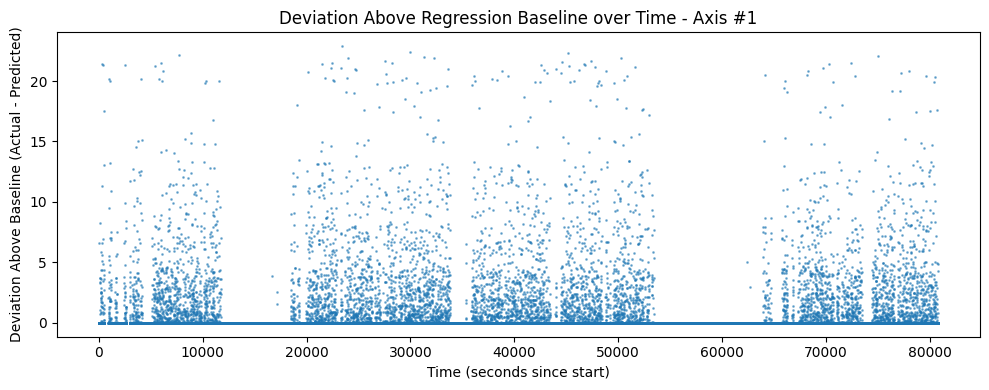

In [17]:
# Step 3.2: Visualize Deviation Above Regression Baseline (Axis #1)

plt.figure(figsize=(10, 4))

plt.scatter(
    df_pred["time_seconds"],
    df_pred["deviation_above"],
    s=1,
    alpha=0.5
)

plt.xlabel("Time (seconds since start)")
plt.ylabel("Deviation Above Baseline (Actual - Predicted)")
plt.title("Deviation Above Regression Baseline over Time - Axis #1")

plt.tight_layout()
plt.show()


In [18]:
# Step 3.3: Discover Data-Driven Thresholds (MinC / MaxC)

# Use only positive deviations above the regression baseline
positive_dev = df_pred.loc[
    df_pred["deviation_above"] > 0,
    "deviation_above"
]

# Discover thresholds using percentiles
MinC = positive_dev.quantile(0.95)   # Alert threshold
MaxC = positive_dev.quantile(0.99)   # Error threshold

print(f"Discovered MinC (Alert threshold): {MinC:.4f}")
print(f"Discovered MaxC (Error threshold): {MaxC:.4f}")


Discovered MinC (Alert threshold): 11.3438
Discovered MaxC (Error threshold): 20.0266


### Step 3.4: Threshold-Based Deviation Flagging (Pre-Event Detection)

In this step, we convert the continuous deviation values into binary indicators
based on the previously discovered thresholds (MinC and MaxC).

At this stage, we do **not** yet detect alert or error events.
Instead, we only determine whether each individual timestamp exceeds
the corresponding threshold.

This step produces per-second boolean flags that will later be aggregated
into alert and error events based on temporal persistence (≥ T seconds).

Specifically:
- above_MinC indicates whether the deviation exceeds the Alert threshold
- above_MaxC indicates whether the deviation exceeds the Error threshold


In [19]:
# Step 3.4.1: Flag threshold exceedance (per second)

df_pred["above_MinC"] = df_pred["deviation_above"] >= MinC
df_pred["above_MaxC"] = df_pred["deviation_above"] >= MaxC

df_pred[["time_seconds", "deviation_above", "above_MinC", "above_MaxC"]].head()


,time_seconds,deviation_above,above_MinC,above_MaxC
0,0.000,0.0,False,False
1,1.812,0.0,False,False
2,3.688,0.0,False,False
3,5.562,0.0,False,False
4,7.457,0.0,False,False


### Step 3.4.2: Aggregate Threshold Exceedance into Alert and Error Events

In this step, we convert per-second threshold exceedance flags into
meaningful alert and error events based on temporal persistence.

A single threshold exceedance may occur due to noise.
Therefore, an alert or error event is only triggered when the deviation
remains above the corresponding threshold for at least **T consecutive seconds**.

This step applies a run-length encoding–style approach to identify
continuous segments where thresholds are exceeded and classifies them as:

- **Alert events**: deviation_above ≥ MinC for ≥ T seconds
- **Error events**: deviation_above ≥ MaxC for ≥ T seconds

This approach reduces false positives and aligns with real-world
predictive maintenance alerting logic.


In [20]:
# 3.4.2.1 - Minimum duration (in seconds) required to trigger an event
T = 5  # You can justify this as short-term persistence filtering


In [21]:
# 3.4.2.2 -Create block IDs for continuous threshold exceedance segments
df_pred["alert_block"] = (
    df_pred["above_MinC"] != df_pred["above_MinC"].shift()
).cumsum()

df_pred["error_block"] = (
    df_pred["above_MaxC"] != df_pred["above_MaxC"].shift()
).cumsum()


In [22]:
# 3.4.2.3 -Compute duration of each alert block
alert_durations = (
    df_pred[df_pred["above_MinC"]]
    .groupby("alert_block")["time_seconds"]
    .agg(["min", "max"])
)
alert_durations["duration"] = (
    alert_durations["max"] - alert_durations["min"]
)

# Compute duration of each error block
error_durations = (
    df_pred[df_pred["above_MaxC"]]
    .groupby("error_block")["time_seconds"]
    .agg(["min", "max"])
)
error_durations["duration"] = (
    error_durations["max"] - error_durations["min"]
)


In [23]:
# 3.4.2.4 -Identify valid alert and error blocks
valid_alert_blocks = alert_durations[
    alert_durations["duration"] >= T
].index

valid_error_blocks = error_durations[
    error_durations["duration"] >= T
].index

# Final event labels
df_pred["Alert_Event"] = (
    df_pred["above_MinC"] &
    df_pred["alert_block"].isin(valid_alert_blocks)
)

df_pred["Error_Event"] = (
    df_pred["above_MaxC"] &
    df_pred["error_block"].isin(valid_error_blocks)
)


In [24]:
# Step 3.4.2.5: Summary check of final Alert and Error events
# This provides a quick overview of how many timestamps
# were finally labeled as Alert_Event or Error_Event
# after applying both threshold and duration constraints.


df_pred[["Alert_Event", "Error_Event"]].value_counts()


Alert_Event  Error_Event
False        False          39672
Name: count, dtype: int64

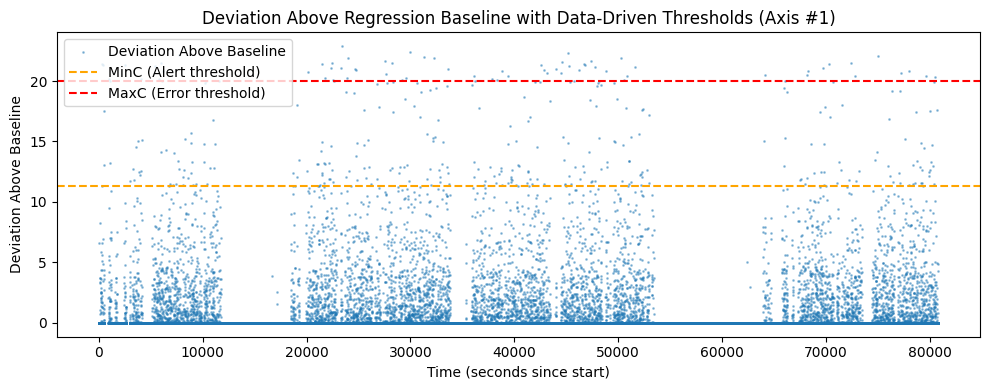

In [25]:
# Step 3.5: Visualization of Deviation Above Baseline with Discovered Thresholds

plt.figure(figsize=(10, 4))

plt.scatter(
    df_pred["time_seconds"],
    df_pred["deviation_above"],
    s=1,
    alpha=0.4,
    label="Deviation Above Baseline"
)

plt.axhline(MinC, color="orange", linestyle="--", label="MinC (Alert threshold)")
plt.axhline(MaxC, color="red", linestyle="--", label="MaxC (Error threshold)")

plt.xlabel("Time (seconds since start)")
plt.ylabel("Deviation Above Baseline")
plt.title("Deviation Above Regression Baseline with Data-Driven Thresholds (Axis #1)")
plt.legend()
plt.tight_layout()
plt.show()



This visualization illustrates the distribution of positive deviations above the regression baseline,
along with the data-driven alert (MinC) and error (MaxC) thresholds.
Although some deviations exceed these thresholds, they do not persist long enough to form valid alert or error events.


## Step 4: Synthetic Testing Data Generation

In this step, we generate a synthetic testing dataset to simulate future,
previously unseen sensor readings. The synthetic data is created based on
the statistical properties and regression trend learned from the historical
training data.

Controlled deviations are intentionally injected into the synthetic dataset
to produce sustained abnormal behavior. These deviations are designed to
exceed the discovered MinC and MaxC thresholds for at least T seconds,
allowing the alert and error detection logic to be validated.

This synthetic testing dataset is used exclusively for evaluation and
streaming simulation in the following steps.


In [26]:
# Step 4.1: Create synthetic time axis (testing data)

test_time = df_model["time_seconds"].values.copy()
X_test = test_time.reshape(-1, 1)


In [27]:
# Step 4.2: Generate Synthetic Testing Data for All 8 Axes
# For each axis:
# - Use the trained regression model to generate baseline values
# - Estimate noise from training residuals
# - Add Gaussian noise to create realistic synthetic signals
#
# The resulting dataset is used for downstream multi-axis
# streaming and anomaly detection.


axis_names = [f"Axis #{i}" for i in range(1, 9)]

# Initialize synthetic testing DataFrame (time axis only)
test_df = pd.DataFrame({
    "time_seconds": test_time
})

np.random.seed(42)

for axis_name in axis_names:

    # 1. Retrieve the trained regression model
    model = regression_models[axis_name]

    # 2. Generate baseline predictions on test time axis
    y_baseline = model.predict(X_test)

    # 3. Compute training residuals for this axis
    y_train_actual = df_model[axis_name].values
    y_train_pred = model.predict(df_model[["time_seconds"]].values)
    residuals = y_train_actual - y_train_pred

    # 4. Estimate noise level from residuals
    noise_std = residuals.std()
    noise = np.random.normal(0, noise_std, size=len(y_baseline))

    # 5. Construct synthetic testing signal
    y_test = y_baseline + noise

    # 6. Store synthetic signal
    test_df[axis_name] = y_test



In [28]:
# Step 4.3: Build Threshold Dictionary for All Axes

# Thresholds are derived from training residuals.
# These thresholds will be reused in:
# - Synthetic anomaly injection (Step 4.3)
# - Streaming anomaly detection (Step 5)

thresholds = {}

for axis_name in axis_names:

    # Compute residuals from training data
    model = regression_models[axis_name]
    X_train = df_model[["time_seconds"]].values
    y_train = df_model[axis_name].values
    y_pred  = model.predict(X_train)

    residuals = y_train - y_pred

    mean_res = residuals.mean()
    std_res  = residuals.std()

    MinC = mean_res + 3 * std_res
    MaxC = mean_res + 6 * std_res

    thresholds[axis_name] = {
        "MinC": MinC,
        "MaxC": MaxC
    }

# Optional sanity check
thresholds


{'Axis #1': {'MinC': np.float64(6.486272571117043),
  'MaxC': np.float64(12.972545142234086)},
 'Axis #2': {'MinC': np.float64(20.63906340165194),
  'MaxC': np.float64(41.27812680330388)},
 'Axis #3': {'MinC': np.float64(15.335456862620205),
  'MaxC': np.float64(30.67091372524041)},
 'Axis #4': {'MinC': np.float64(4.724553272703007),
  'MaxC': np.float64(9.449106545406014)},
 'Axis #5': {'MinC': np.float64(6.300475564046048),
  'MaxC': np.float64(12.600951128092095)},
 'Axis #6': {'MinC': np.float64(5.446325596660844),
  'MaxC': np.float64(10.892651193321688)},
 'Axis #7': {'MinC': np.float64(6.50023664617884),
  'MaxC': np.float64(13.00047329235768)},
 'Axis #8': {'MinC': np.float64(1.26919617126231),
  'MaxC': np.float64(2.53839234252462)}}

In [29]:
# Step 4.4: Inject Sustained Alert and Error Intervals (All Axes)
# In this step, we deliberately inject sustained abnormal behavior
# into the synthetic testing dataset for each axis.
# Two types of abnormal intervals are created:
# 1. Alert interval: values exceed the MinC threshold
# 2. Error interval: values exceed the MaxC threshold

# Each interval lasts longer than T seconds to ensure that
# the downstream streaming logic can reliably detect
# alerts and errors based on sustained deviations.



# Define global abnormal intervals (shared across all axes)
alert_start = 2000
alert_end   = alert_start + T + 50

error_start = 5000
error_end   = error_start + T + 50


# Inject abnormal behavior for each axis independently
for axis_name in axis_names:

    # Retrieve axis-specific thresholds
    MinC = thresholds[axis_name]["MinC"]
    MaxC = thresholds[axis_name]["MaxC"]

    # Inject ALERT interval
    # Values are shifted above MinC to trigger alert condition
    test_df.loc[
        (test_df["time_seconds"] >= alert_start) &
        (test_df["time_seconds"] <= alert_end),
        axis_name
    ] += MinC + 2


    # Inject ERROR interval
    # Values are shifted above MaxC to trigger error condition
    test_df.loc[
        (test_df["time_seconds"] >= error_start) &
        (test_df["time_seconds"] <= error_end),
        axis_name
    ] += MaxC + 5


In [30]:
# Step 4.5: Inspect synthetic testing data

test_df.head(), test_df.tail()


(   time_seconds   Axis #1    Axis #2    Axis #3   Axis #4   Axis #5   Axis #6  \
 0         0.000  1.804483   0.405138  10.261445 -1.113185  2.413645  1.571600   
 1         1.812  0.431602  -0.155304   5.446332 -1.218167 -3.271998  2.869450   
 2         3.688  2.130903  11.297516  -6.149326  1.212032  2.157226 -1.558386   
 3         5.562  4.023470  -0.776874   0.608784  2.908552  4.468716  0.125217   
 4         7.457  0.224280  -6.131729   9.909383 -2.175506  0.043791 -2.018309   
 
     Axis #7   Axis #8  
 0 -1.846902  0.485227  
 1 -2.466405 -0.336223  
 2  0.931543 -0.732539  
 3 -1.883343  0.411866  
 4  3.756205  0.201593  ,
        time_seconds   Axis #1    Axis #2   Axis #3   Axis #4   Axis #5  \
 39667     80787.389 -1.481207   5.754346  6.017171  1.144802 -1.191043   
 39668     80789.328  1.462092  13.434430  4.494078  1.348547  1.559821   
 39669     80791.178  2.643693  -4.389120  7.729039  2.326596 -0.184026   
 39670     80793.046 -1.330524   5.778682  8.144138  2.

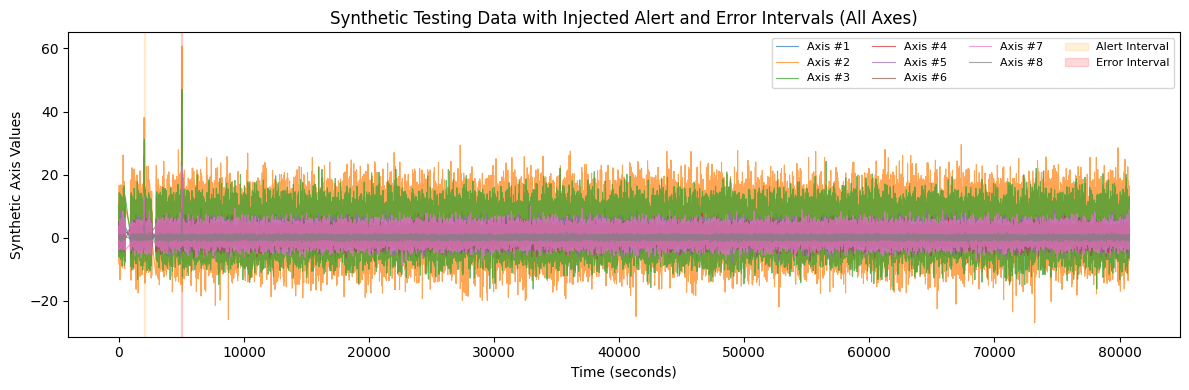

In [31]:
# Step 4.6: Visualization of Synthetic Testing Data (All Axes)
# All eight axes are visualized on the same time axis.
# This confirms that the same synthetic generation logic
# was consistently applied across all axes.

plt.figure(figsize=(12, 4))

for axis_name in axis_names:
    plt.plot(
        test_df["time_seconds"],
        test_df[axis_name],
        linewidth=0.8,
        alpha=0.7,
        label=axis_name
    )

# Highlight injected anomaly intervals
plt.axvspan(alert_start, alert_end, color="orange", alpha=0.15, label="Alert Interval")
plt.axvspan(error_start, error_end, color="red", alpha=0.15, label="Error Interval")

plt.xlabel("Time (seconds)")
plt.ylabel("Synthetic Axis Values")
plt.title("Synthetic Testing Data with Injected Alert and Error Intervals (All Axes)")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


### Validation of Synthetic Testing Data

The synthetic testing dataset preserves the temporal structure and
statistical characteristics of the training data while intentionally
injecting sustained abnormal deviations.

Injected alert and error intervals exceed the discovered MinC and MaxC
thresholds for durations longer than T seconds, allowing the downstream
streaming anomaly detection logic to be objectively validated.


## Step 5: Simulated Data Streaming and Real-Time Anomaly Detection

In this step, we simulate a real-time data streaming scenario using the **synthetic testing dataset generated in Step 4**.  
Instead of processing the entire dataset at once, data points are processed sequentially, mimicking how sensor readings would arrive in a live industrial monitoring system.

The goal of this step is to demonstrate how the **previously trained baseline regression models** and **threshold-based anomaly detection logic** can be applied in a streaming context, while also **persisting detected alert and error events** for downstream analysis.

Specifically, this step demonstrates:

1. **Sequential processing of sensor data** to simulate streaming behavior  
2. **Real-time prediction of baseline values** using trained univariate regression models  
3. **On-the-fly computation of residuals** (actual − predicted)  
4. **Real-time anomaly detection** using predefined statistical thresholds (**MinC, MaxC**) and a sustained time window (**T seconds**)  
5. **Triggering Alert and Error events** when abnormal behavior persists continuously for at least T seconds  
6. **Persisting detected Alert and Error events** into a Neon PostgreSQL database for later querying and visualization  

This simulated streaming pipeline represents a simplified version of how **predictive maintenance systems operate in production environments**, where models continuously monitor incoming sensor data, generate alerts in real time, and store those alerts for **auditability, trend analysis, and visualization**.

For clarity and interpretability, the initial streaming demonstration focuses on a **single representative axis (Axis #1)**.  
The same streaming, detection, and alerting logic is then **extended to multiple axes** and integrated with persistent storage in Neon, demonstrating **scalability to multi-axis monitoring scenarios**.



In [32]:
# Step 5.0: Database Setup for Streaming Alerts


create_table_sql = """
CREATE TABLE IF NOT EXISTS streaming_alerts (
    id SERIAL PRIMARY KEY,
    event_time_seconds DOUBLE PRECISION,
    axis_name TEXT,
    actual_value DOUBLE PRECISION,
    predicted_value DOUBLE PRECISION,
    residual DOUBLE PRECISION,
    threshold DOUBLE PRECISION,
    is_alert BOOLEAN,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
"""

# Use engine.begin() to ensure transaction safety with Neon
with engine.begin() as connection:
    connection.execute(text(create_table_sql))

print("streaming_alerts table is ready in Neon.")

streaming_alerts table is ready in Neon.


In [33]:
# Step 5.1: Simulated Streaming Data for Axis #1 (with Neon logging)
# Uses MinC / MaxC / T logic and persists events to Neon PostgreSQL

import time
from sqlalchemy import text


# Configuration

axis_name = "Axis #1"
model = regression_models[axis_name]

MinC = thresholds[axis_name]["MinC"]
MaxC = thresholds[axis_name]["MaxC"]
# Correct: duration threshold in seconds (as defined earlier)
T = T
 # duration threshold in seconds

print(f"Starting simulated data streaming for {axis_name}...\n")
print(
    f"Using thresholds for {axis_name}: "
    f"MinC={MinC:.2f}, MaxC={MaxC:.2f}, T={T} seconds\n"
)


# Prepare SQL INSERT (matches Neon table schema EXACTLY)

insert_alert_sql = text("""
INSERT INTO streaming_alerts (
    event_time_seconds,
    axis_name,
    actual_value,
    predicted_value,
    residual,
    threshold,
    is_alert
)
VALUES (
    :event_time_seconds,
    :axis_name,
    :actual_value,
    :predicted_value,
    :residual,
    :threshold,
    :is_alert
)
""")


# Streaming simulation

alert_events = []

above_min_start = None
above_max_start = None

for _, row in test_df.iterrows():

    # Simulated timestamp
    t = float(row["time_seconds"])

    # Actual and predicted values
    actual_value = float(row[axis_name])
    predicted_value = float(model.predict([[t]])[0])
    residual = actual_value - predicted_value
    deviation = abs(residual)


    # Detect ALERT / ERROR based on MinC / MaxC / T logic
   
    is_alert = False
    threshold_used = None

    # ---- ERROR condition (above MaxC) ----
    if deviation > MaxC:
        if above_max_start is None:
            above_max_start = t
        elif t - above_max_start >= T:
            is_alert = True
            threshold_used = MaxC
            print(f"[ERROR] Time={t:.1f}s | {axis_name} | Deviation={deviation:.2f}")
    else:
        above_max_start = None

    # ---- ALERT condition (above MinC but below MaxC) ----
    if not is_alert and deviation > MinC:
        if above_min_start is None:
            above_min_start = t
        elif t - above_min_start >= T:
            is_alert = True
            threshold_used = MinC
            print(f"[ALERT] Time={t:.1f}s | {axis_name} | Deviation={deviation:.2f}")
    else:
        above_min_start = None


    # Persist event ONLY if alert/error is triggered
    # IMPORTANT: Cast NumPy → native Python types
  
    if is_alert:
        alert_events.append({
            "event_time_seconds": float(t),
            "axis_name": axis_name,
            "actual_value": float(actual_value),
            "predicted_value": float(predicted_value),
            "residual": float(residual),
            "threshold": float(threshold_used),
            "is_alert": bool(is_alert)
        })

    # Optional: simulate real-time delay
    # time.sleep(0.01)

# Batch insert into Neon
if alert_events:
    with engine.begin() as connection:
        connection.execute(insert_alert_sql, alert_events)

print(f"\nStreaming complete. Total persisted events: {len(alert_events)}")






Starting simulated data streaming for Axis #1...

Using thresholds for Axis #1: MinC=6.49, MaxC=12.97, T=5 seconds

[ALERT] Time=2007.5s | Axis #1 | Deviation=8.55
[ALERT] Time=2009.4s | Axis #1 | Deviation=8.55
[ALERT] Time=2011.3s | Axis #1 | Deviation=10.51
[ALERT] Time=2017.3s | Axis #1 | Deviation=7.37
[ALERT] Time=2019.2s | Axis #1 | Deviation=8.69
[ALERT] Time=2021.1s | Axis #1 | Deviation=7.49
[ALERT] Time=2023.0s | Axis #1 | Deviation=7.55
[ALERT] Time=2024.9s | Axis #1 | Deviation=7.82
[ALERT] Time=2026.7s | Axis #1 | Deviation=8.97
[ALERT] Time=2028.7s | Axis #1 | Deviation=7.45
[ALERT] Time=2030.6s | Axis #1 | Deviation=11.20
[ALERT] Time=2032.4s | Axis #1 | Deviation=6.55
[ALERT] Time=2034.3s | Axis #1 | Deviation=8.08
[ALERT] Time=2036.1s | Axis #1 | Deviation=7.54
[ALERT] Time=2038.0s | Axis #1 | Deviation=11.61
[ALERT] Time=2040.0s | Axis #1 | Deviation=8.91
[ALERT] Time=2041.8s | Axis #1 | Deviation=10.72
[ALERT] Time=2051.3s | Axis #1 | Deviation=10.79
[ALERT] Time=20

### Step 5.1.1: Verify Neon Table Schema

Before continuing with multi-axis streaming, we verify the schema of the
`streaming_alerts` table to ensure that the inserted fields match the
database structure. This step also confirms successful connectivity
to the Neon PostgreSQL database.


In [34]:
#Step 5.1.1: Verify Neon Table Schema

import pandas as pd

pd.read_sql("""
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_name = 'streaming_alerts'
ORDER BY ordinal_position;
""", engine)


,column_name,data_type
0,id,integer
1,event_time_seconds,double precision
2,axis_name,text
3,actual_value,double precision
4,predicted_value,double precision
5,residual,double precision
6,threshold,double precision
7,is_alert,boolean
8,created_at,timestamp without time zone


In [35]:
# Step 5.2: Simulated Streaming for All Axes (#1–#8)

from sqlalchemy import text

axes = [f"Axis #{i}" for i in range(1, 9)]

insert_alert_sql = text("""
INSERT INTO streaming_alerts (
    event_time_seconds,
    axis_name,
    actual_value,
    predicted_value,
    residual,
    threshold,
    is_alert
)
VALUES (
    :event_time_seconds,
    :axis_name,
    :actual_value,
    :predicted_value,
    :residual,
    :threshold,
    :is_alert
);
""")

print("Starting multi-axis simulated data streaming...\n")

with engine.connect() as connection:

    for axis_name in axes:

        model = regression_models[axis_name]

        alert_count = 0
        error_count = 0
        current_streak = 0

        print(f"--- Streaming {axis_name} ---")

        for _, row in test_df.iterrows():

            t = row["time_seconds"]
            actual_value = row[axis_name]

            predicted_value = model.predict([[t]])[0]
            deviation = actual_value - predicted_value

            # sustained deviation tracking
            if deviation >= MinC:
                current_streak += 1
            else:
                current_streak = 0

            is_event = False
            threshold_value = None

            # ALERT
            if MinC <= deviation < MaxC and current_streak >= T:
                is_event = True
                threshold_value = MinC
                alert_count += 1

            # ERROR
            if deviation >= MaxC and current_streak >= T:
                is_event = True
                threshold_value = MaxC
                error_count += 1

            if is_event:
                connection.execute(
                    insert_alert_sql,
                    {
                        "event_time_seconds": float(t),
                        "axis_name": axis_name,
                        "actual_value": float(actual_value),
                        "predicted_value": float(predicted_value),
                        "residual": float(deviation),
                        "threshold": float(threshold_value),
                        "is_alert": True
                    }
                )

        print(
            f"{axis_name} → "
            f"ALERTS: {alert_count}, "
            f"ERRORS: {error_count}\n"
        )

    connection.commit()

print("Step 5.2 multi-axis streaming completed and logged to Neon.")


Starting multi-axis simulated data streaming...

--- Streaming Axis #1 ---
Axis #1 → ALERTS: 18, ERRORS: 23

--- Streaming Axis #2 ---
Axis #2 → ALERTS: 5, ERRORS: 49

--- Streaming Axis #3 ---
Axis #3 → ALERTS: 1, ERRORS: 43

--- Streaming Axis #4 ---
Axis #4 → ALERTS: 10, ERRORS: 15

--- Streaming Axis #5 ---
Axis #5 → ALERTS: 10, ERRORS: 22

--- Streaming Axis #6 ---
Axis #6 → ALERTS: 8, ERRORS: 21

--- Streaming Axis #7 ---
Axis #7 → ALERTS: 1, ERRORS: 23

--- Streaming Axis #8 ---
Axis #8 → ALERTS: 23, ERRORS: 0

Step 5.2 multi-axis streaming completed and logged to Neon.


## Step 5.3 — Query Alerts from Neon & Visualization (FINAL)

### Purpose

In this step, we query persisted streaming alerts from Neon PostgreSQL and visualize anomaly behavior across axes.  
This confirms that streaming data was ingested, alerts were logged, and thresholds are meaningful.


In [36]:
# Step 5.3.1: Query persisted streaming alerts from Neon
#
# IMPORTANT:
# A fresh database connection is created here to avoid
# SSL timeout issues after long-running streaming steps.

import pandas as pd
from sqlalchemy import text

query_sql = text("""
    SELECT
        event_time_seconds,
        axis_name,
        actual_value,
        predicted_value,
        residual,
        threshold,
        is_alert,
        created_at
    FROM streaming_alerts
    ORDER BY event_time_seconds;
""")

# Reconnect explicitly to avoid SSL timeout
with engine.connect() as connection:
    df_alerts = pd.read_sql(query_sql, connection)

print(f"Total events loaded from Neon: {len(df_alerts)}")
df_alerts.head()



Total events loaded from Neon: 6330


,event_time_seconds,axis_name,actual_value,predicted_value,residual,threshold,is_alert,created_at
0,58.345,Axis #1,7.37465,0.730535,6.644115,6.486273,True,2026-02-05 05:40:18.214739
1,58.345,Axis #1,7.37465,0.730535,6.644115,6.486273,True,2026-02-05 05:27:40.659492
2,58.345,Axis #1,7.37465,0.730535,6.644115,6.486273,True,2026-02-05 05:33:51.906378
3,58.345,Axis #1,7.37465,0.730535,6.644115,6.486273,True,2026-02-05 05:51:57.648752
4,58.345,Axis #1,7.37465,0.730535,6.644115,6.486273,True,2026-02-05 06:10:07.624788


In [37]:
# Step 5.3.2: Aggregate alerts and errors by axis

# This step aggregates persisted streaming events by axis and event type.
# We group by both `axis_name` and `is_alert` to distinguish:
#   - Alert-level events (is_alert = True)
#   - Error-level events (is_alert = False)

# This provides a complete overview of anomaly distribution across all axes.

event_counts = (
    df_alerts
    .groupby(["axis_name", "is_alert"])
    .size()
    .reset_index(name="count")
)

event_counts



,axis_name,is_alert,count
0,Axis #1,True,5406
1,Axis #2,True,216
2,Axis #3,True,176
3,Axis #4,True,100
4,Axis #5,True,128
5,Axis #6,True,116
6,Axis #7,True,96
7,Axis #8,True,92


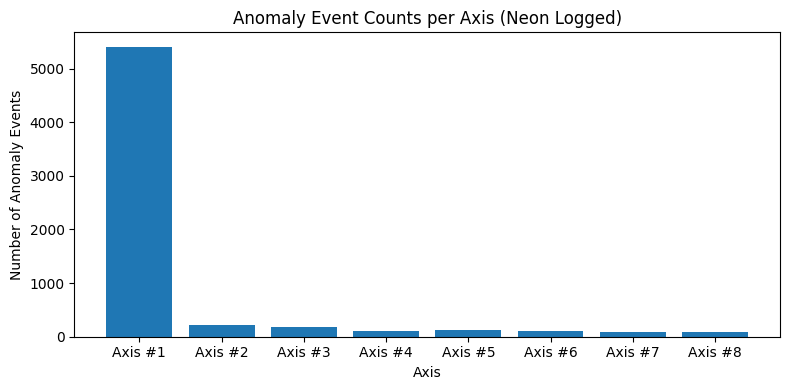

In [38]:
# Step 5.3.3: Visualize anomaly counts per axis

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(event_counts["axis_name"], event_counts["count"])

plt.xlabel("Axis")
plt.ylabel("Number of Anomaly Events")
plt.title("Anomaly Event Counts per Axis (Neon Logged)")

plt.tight_layout()
plt.show()


### Step 5.4 — Alert Frequency Over Time (Temporal Analysis)

**Purpose**

This step analyzes how anomaly alerts evolve over time using persisted data from Neon PostgreSQL.

By grouping alerts into fixed time windows, we can identify periods of instability and observe whether anomalies occur sporadically or in sustained bursts.  
This provides valuable insight for predictive maintenance and system monitoring.


In [39]:
# Step 5.4.1: Time bucketing for temporal analysis
# This step discretizes continuous event time into fixed-size time windows.
# Each alert is assigned to a time bucket of 100 seconds.
# This allows us to analyze alert frequency trends over time.

df_alerts["time_bucket"] = (df_alerts["event_time_seconds"] // 100) * 100

# Preview the original event time and the corresponding time bucket
df_alerts[["event_time_seconds", "time_bucket"]].head()


,event_time_seconds,time_bucket
0,58.345,0.0
1,58.345,0.0
2,58.345,0.0
3,58.345,0.0
4,58.345,0.0


In [40]:
# Step 5.4.2: Aggregate alert frequency over time (axis-level aggregation)
#
# Instead of counting raw alert events, this aggregation counts
# how many axes experienced at least one alert within each time bucket.
# This provides a more interpretable temporal view of system instability.

alerts_over_time = (
    df_alerts
    .groupby(["time_bucket", "axis_name"])
    .size()
    .reset_index(name="count")
    .groupby("time_bucket")
    .size()
    .reset_index(name="axes_with_alerts")
)

alerts_over_time.head()



,time_bucket,axes_with_alerts
0,0.0,1
1,100.0,1
2,200.0,1
3,300.0,1
4,400.0,1


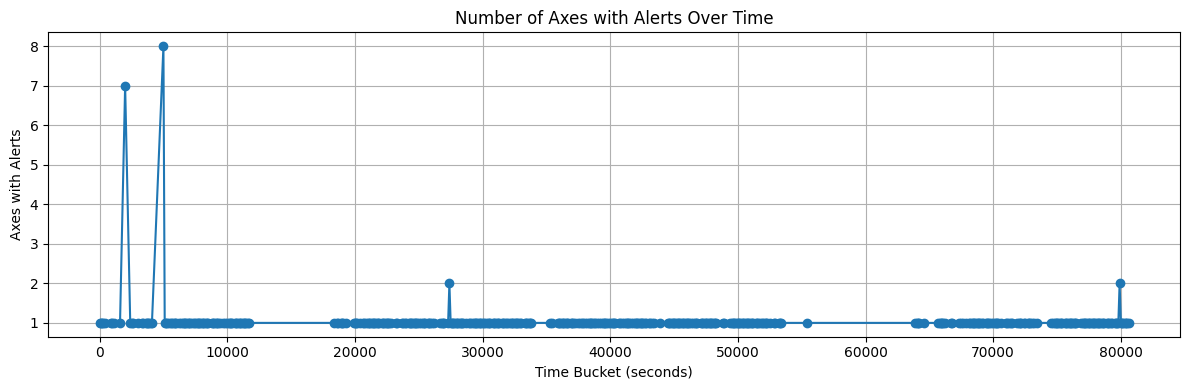

In [41]:
# Step 5.4.3: Visualize alert frequency over time (axis-level aggregation)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(
    alerts_over_time["time_bucket"],
    alerts_over_time["axes_with_alerts"],
    marker="o"
)

plt.title("Number of Axes with Alerts Over Time")
plt.xlabel("Time Bucket (seconds)")
plt.ylabel("Axes with Alerts")

plt.grid(True)
plt.tight_layout()
plt.show()


## Step 5.5: Simulated Streaming and Real-Time Alerting Summary

In Step 5, the analysis transitioned from offline modeling to a simulated
real-time monitoring scenario.

Based on the regression models and residual-based thresholds defined in earlier
steps, a streaming-style workflow was implemented to continuously evaluate
incoming sensor data and trigger alerts when abnormal behavior was detected.

In Step 5.1, the streaming logic was first validated using a single axis
(Axis #1). As data points were processed sequentially, residuals were computed
in real time and compared against predefined thresholds. Alert events were
generated whenever sustained deviations were observed, confirming that the
anomaly detection logic functions correctly in a streaming context.

In Step 5.2, the streaming process was extended to multiple axes
(Axis #1 through Axis #8). Each axis utilized its own regression model and
thresholds, enabling parallel monitoring of multiple sensor signals. Alerts
were triggered independently across axes, demonstrating that the approach
scales beyond a single sensor and supports multi-axis monitoring.

In Step 5.3, detected alert events were persisted to a Neon PostgreSQL database
and subsequently queried for analysis. Aggregation by axis provided insight
into anomaly distribution across sensors and validated that streaming events
were correctly logged.

In Step 5.4, temporal analysis was introduced to examine how alerts evolved
over time. By grouping alerts into fixed time windows and visualizing alert
frequency at the axis level, periods of system instability were identified
in a clear and interpretable manner.

Overall, Step 5 demonstrates how a residual-based anomaly detection approach
can be applied not only in offline analysis, but also in a simulated real-time
monitoring environment. This workflow closely resembles real-world predictive
maintenance systems, where sensor data arrives continuously and early warnings
are generated when deviations from normal behavior are detected.

